# 06 Final Comparison and Report Notes

This notebook turns the earlier exploration into final comparison tables.

## whst is being done:
- Compare the original retained models and the new metadata-aware extensions side by side.
- Summarize what each variant contributes.

## Test ranking by NDCG@10 (retained + metadata extensions)

,rank,model,precision@10,recall@10,ndcg@10,users_evaluated,eval_split,metadata_mode,fusion,alpha
0,1,EASEMeta-ratingPrior-a0.03,0.044929,0.066133,0.086694,7080,test,NaN,NaN,NaN
1,2,RP3betaMetaLowRank-categoryContent,0.043602,0.066083,0.086520,7080,test,NaN,NaN,NaN
2,3,EASE-Binary-3000,0.044746,0.065984,0.086413,7080,test,NaN,NaN,NaN
3,4,EASEMeta-category_char-score_blend-a0.5,0.044831,0.065467,0.086227,7080,test,category_char,score_blend,0.5
4,5,RP3beta-a0.9-b0.4-t400,0.043121,0.064997,0.085032,7080,test,NaN,NaN,NaN
5,6,RP3betaMeta-category_char-rerank-a0.1,0.043404,0.064650,0.084975,7080,test,category_char,rerank,0.1
6,7,ItemKNN-BM25-K320,0.042994,0.063505,0.083244,7080,test,NaN,NaN,NaN
7,8,UserCF,0.042754,0.063452,0.081960,7080,test,NaN,NaN,NaN
8,9,Popularity,0.037797,0.058550,0.071684,7080,test,NaN,NaN,NaN
9,10,SVD,0.022797,0.027715,0.038456,7080,test,NaN,NaN,NaN


## Validation ranking by NDCG@10 (retained + metadata extensions)

,rank,model,precision@10,recall@10,ndcg@10,users_evaluated,eval_split,metadata_mode,fusion,alpha
0,1,EASEMeta-category_char-score_blend-a0.5,0.042429,0.067036,0.084453,7568,val,category_char,score_blend,0.5
1,2,EASEMeta-ratingPrior-a0.03,0.041596,0.065473,0.083704,7568,val,NaN,NaN,NaN
2,3,EASE-Binary-3000,0.041662,0.066305,0.083574,7568,val,NaN,NaN,NaN
3,4,RP3betaMetaLowRank-categoryContent,0.040077,0.065482,0.082350,7568,val,NaN,NaN,NaN
4,5,RP3betaMeta-category_char-rerank-a0.1,0.040645,0.065037,0.082348,7568,val,category_char,rerank,0.1
5,6,RP3beta-a0.9-b0.4-t400,0.039826,0.065071,0.081088,7568,val,NaN,NaN,NaN
6,7,ItemKNN-BM25-K320,0.040169,0.063663,0.080379,7568,val,NaN,NaN,NaN
7,8,UserCF,0.039191,0.062940,0.079269,7568,val,NaN,NaN,NaN
8,9,Popularity,0.034567,0.057383,0.067148,7568,val,NaN,NaN,NaN
9,10,SVD,0.023163,0.030413,0.039400,7568,val,NaN,NaN,NaN


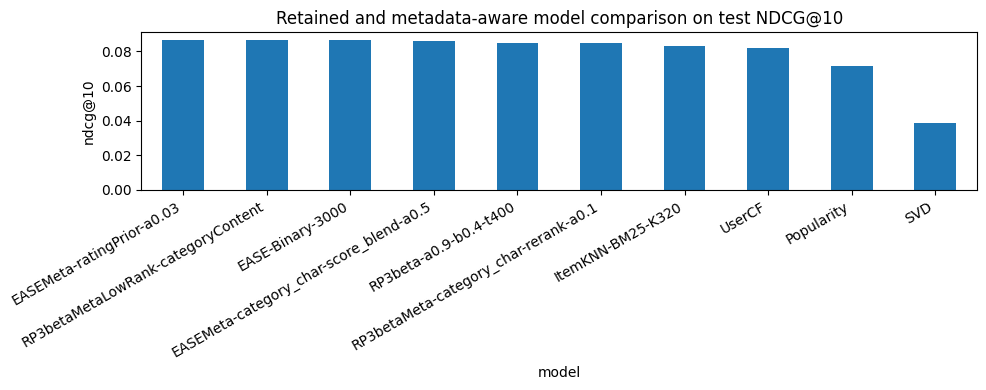

In [1]:
import pandas as pd
from IPython.display import display, Markdown

from analysis.shared_utils import RESULTS_DIR, load_retained_results, metric_delta_table, plot_metric_bars, rank_models

comparison_test = load_retained_results("test")
comparison_val = load_retained_results("val")

metadata_test = pd.concat(
    [
        pd.read_csv(RESULTS_DIR / "ease_metadata_test_best.csv"),
        pd.read_csv(RESULTS_DIR / "ease_metadata_best_test.csv"),
        pd.read_csv(RESULTS_DIR / "rp3beta_metadata_test_best.csv"),
        pd.read_csv(RESULTS_DIR / "rp3beta_metadata_best_test.csv"),
    ],
    ignore_index=True,
    sort=False,
)

metadata_val = pd.concat(
    [
        pd.read_csv(RESULTS_DIR / "ease_metadata_val_summary.csv").head(1),
        pd.read_csv(RESULTS_DIR / "ease_metadata_best_val.csv"),
        pd.read_csv(RESULTS_DIR / "rp3beta_metadata_val_summary.csv").head(1),
        pd.read_csv(RESULTS_DIR / "rp3beta_metadata_best_val.csv"),
    ],
    ignore_index=True,
    sort=False,
)

combined_test = pd.concat([comparison_test, metadata_test], ignore_index=True, sort=False)
combined_val = pd.concat([comparison_val, metadata_val], ignore_index=True, sort=False)

ranked_test = rank_models(combined_test, metric="ndcg@10")
ranked_val = rank_models(combined_val, metric="ndcg@10")

display(Markdown("## Test ranking by NDCG@10 (retained + metadata extensions)"))
display(ranked_test)

display(Markdown("## Validation ranking by NDCG@10 (retained + metadata extensions)"))
display(ranked_val)

plot_metric_bars(combined_test, metric="ndcg@10", title="Retained and metadata-aware model comparison on test NDCG@10");

### Conclusion
The team built one shared implicit feedback pipeline, compared three distinct interaction only model families under the same top-K metrics, and then extended EASE and RP3beta with metadata aware variants. ItemKNN remains the unchanged retained Variant C model, while the metadata story now includes both old LightFM exploration and the newer pushed phase2 metadata implementations.